# Simple System

In this example, we build a small feedback system using the `syssimx` framework. The system consists of three components:
- a constant source,
- a subtractor,
- and an integrator.

These components form a feedback loop, and we will simulate the system over time to observe its behavior.

![System Diagram](figures/first_system_graph.svg)

## Overview

1. We define each component as a subclass of `CoSimComponent`, specify their input/output ports, and implement their behavior.

2. We then connect them with `Connection` objects and run the simulation with a `System` instance.

3. Finally, we visualize the results using `matplotlib` and compare them to the analytical solution.


## Learning Goals
By completing this example, you will learn:

- How to define custom co-simulation components using the `CoSimComponent` base class.
- How to connect components to form a system using the `Connection` class.
- How to initialize and simulate a system using the `System` class.
- How to retrieve and visualize the simulation results.

## Prerequisites and Setup

We require the following packages:
- `syssimx`
- `numpy`
- `matplotlib`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from syssimx import CoSimComponent, Connection, System
from syssimx.core import PortSpec, PortType
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

## Implementation

We start by defining the three components: `ConstantSource`, `Subtractor`, and `Integrator`.


### `ConstantSource` Component

- This component outputs a constant real value.
- We do not need to implement any specific logic in the initialization or time-stepping methods since the output is constant.

In [2]:
class ConstantSource(CoSimComponent):
    """A source component that outputs a constant value."""

    def __init__(self, name: str, value: float = 1.0):
        super().__init__(name, group="Source")
        self.value = value
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None):
        self.outputs["y"].set(self.value, t)

### `Subtractor` Component

- This component takes two real inputs and outputs their difference (`pos - neg`).
- The subtraction is performed in `_update_output_states`.
- The component has no dynamic state, so `_do_step_internal` is empty.
- The component implements `evaluate_outputs` to compute direct feedthrough behavior.
- **Direct feedthrough** means an output depends on inputs in the same time step.


In [3]:
class Subtractor(CoSimComponent):
    """A subtractor component that subtracts its two input signals.
    
    diff = input1 - input2
    """
    def __init__(self, name="Subtractor"):
        super().__init__(name, group="Subtractor")
        self.input_specs.update({
            "pos": PortSpec("pos", PortType.REAL, direction="in"),
            "neg": PortSpec("neg", PortType.REAL, direction="in"),
        })
        self.output_specs.update({"diff": PortSpec("diff", PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t):
        """Update the output port states based on the current input values."""
        input1_value = self.inputs["pos"].get()
        input2_value = self.inputs["neg"].get()
        self.result = input1_value - input2_value
        self.outputs["diff"].set(self.result, t)

    def evaluate_outputs(self, inputs) -> dict:
        """Evaluate outputs based on given inputs."""
        i1 = inputs.get("pos", self.inputs["pos"].get())
        i2 = inputs.get("neg", self.inputs["neg"].get())
        self.outputs["diff"].set(i1 - i2, None)
        return {"diff": i1 - i2}

    def reset(self):
        super().reset()
        self.outputs["diff"].set(0.0)

### `Integrator` Component

- This component integrates its input over time using the explicit Euler method:
$$ x(t + \Delta t) = x(t) + \Delta t \cdot u(t) $$
- The integrator has one state variable `x` updated in `_do_step_internal`.
- The output `y` is the current value of `x`.


In [4]:
class Integrator(CoSimComponent):
    """ An integrator component that integrates its input signal u over time.

    The output y(t) is the integral of the input u(t) with respect to time
    """

    def __init__(self, name="Integrator", x0=0.0):
        super().__init__(name, group="Integrator")
        self.input_specs.update({"u": PortSpec(name="u", type=PortType.REAL, direction="in")})
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out", unit=None, description="Integrated output")})
        self.x0 = x0

    def _initialize_component(self, t0: float) -> None:
        """Initialize the integrator state."""
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        """Perform a simulation step by integrating the input signal."""
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t):
        """Update the output port states."""
        self.outputs["y"].set(self.x, t)

    def reset(self):
        """Reset the integrator state to the initial value."""
        super().reset()
        self.x = self.x0
        self._update_output_states(self.t)


## Instantiation of Components

The three components are instantiated and stored in a list for further processing.

In [5]:
constant_source = ConstantSource(name="ConstSource", value=1.0)

subtractor = Subtractor(name="Subtractor")

integrator = Integrator(name="Integrator", x0=0.0)

components = [constant_source, subtractor, integrator]

## Defining Connections

Components are connected using the `Connection` class.

A `Connection` object is created for each connection between the **output** port of one **source component** and the **input** port of a **destination component**.

A `Connection` object takes the following parameters:
- `src_comp`: The **name** (string) of the source component.
- `src_port`: The **name** (string) of the output port on the source component.
- `dst_comp`: The **name** (string) of the destination component.
- `dst_port`: The **name** (string) of the input port on the destination component.


In [6]:
c1 = Connection(src_comp=constant_source.name,
                src_port=constant_source.output_specs["y"].name,
                dst_comp=subtractor.name,
                dst_port=subtractor.input_specs["pos"].name)

c2 = Connection(src_comp=integrator.name,
                src_port=integrator.output_specs["y"].name,
                dst_comp=subtractor.name,
                dst_port=subtractor.input_specs["neg"].name)

c3 = Connection(src_comp=subtractor.name,
                src_port=subtractor.output_specs["diff"].name,
                dst_comp=integrator.name,
                dst_port=integrator.input_specs["u"].name)

connections = [c1, c2, c3]

By defining these connections, we set up the following system:

\begin{align*}
u(t) & = 1.0 \quad \text{(constant source)} \\
v(t) & = u(t) - y(t) \quad \text{(subtractor)} \\
\frac{dy(t)}{dt} & = v(t) \quad \text{(integrator)}
\end{align*}

We can solve this ODE analytically. With $\dot{y} = 1 - y$ and $y(0) = 0$, the solution is:

$$y(t) = 1 - e^{-t}$$


## Creating the System

A `System` object in the `syssimx` framework represents a collection of interconnected `CoSimComponent` instances.

The main responsibilities of the `System` class include:
- Managing the lifecycle of its components, including initialization and time-stepping
- Handling the connections between components to ensure proper data flow

The following order of operations must be followed when working with a `System` object:
1. **Add Components**: Use `add_component` to register each component.
2. **Add Connections**: Use `add_connection` to define how components are linked.
3. **Configure Parameters**: Set component parameters before initialization.
4. **Initialize the System**: Call `initialize` to prepare the system for simulation.


In [7]:
system = System(name="My First System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

## Visualizing the System Graph

The `syssimx` framework provides a method to visualize the system structure using `graphviz`.

We can instantiate a `SystemGraphVisualizer` object with the `System` object and call `visualize` to generate a graphical representation of the system.

This visualization uses component names, group names, and connections to create a clear diagram of the system architecture.

All components list their input and output ports on the left and right sides, respectively, making it easy to understand how data flows through the system.

**Direct Feedthrough Indication**:

If an **output port name is colored in red**, it indicates that the **port has direct feedthrough**, meaning its output depends directly on its input during the same time step.

**Execution Order**:

In a co-simulation system, the execution order determines the sequence in which components are updated during each simulation step. This is important because the output of one component may depend on the input from another component. If the components are not updated in the correct order, the simulation may produce incorrect results or even fail to run.

For example, in this tutorial:

- The `Subtractor` has direct feedthrough on both inputs, so it must run after its input providers.
- The `Integrator` does not have direct feedthrough so there is no dependency edge from Subtractor to Integrator.
- That yields `ConstSource` and `Integrator` in the first generation and `Subtractor` in the second.

The `syssimx` framework automatically determines the correct execution order based on the connections between components. This ensures that each component receives the most up-to-date inputs during the simulation.


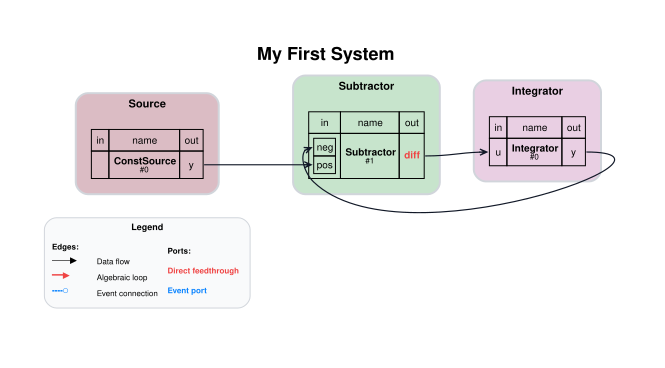

In [8]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize("first_system_graph.svg")

In [9]:
print("Execution order:", system.execution_order)

Execution order: [['ConstSource', 'Integrator'], ['Subtractor']]


This means that the `ConstantSource` and `Integrator` components are updated first, followed by the `Subtractor` component. 

## Running the System Simulation

We can run the simulation using the `run` method of the `System` class. This method takes the following parameters:
- `t0`: The starting time of the simulation.
- `tf`: The ending time of the simulation.
- `dt`: The time step size for the simulation.


In [10]:
t0 = 0.0
tf = 5.0
dt = 0.01

system.run(t0=t0, tf=tf, dt=dt)

## Retrieving History

After the simulation is complete, we can retrieve the history using `get_history`. This returns a dictionary containing time values and data for each component.


After the simulation is complete, we can retrieve the history of the simulation using the `get_history` method of the `System` class. This method returns a dictionary containing the time values and data for each component.

In [11]:
history = system.get_history()

t_vals, data = history['Integrator']
y_vals = data['y']

## Reference Solution

In [12]:
dt_ref = dt / 1000
t_ref_vals = np.arange(t0, tf + dt_ref, dt_ref)
y_ref = 1 - np.exp(-t_ref_vals)

## Visualizing the Results

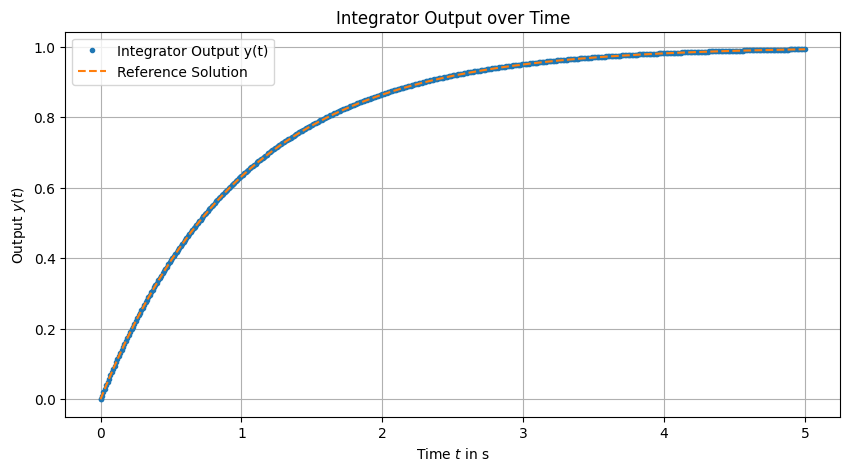

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(t_vals, y_vals, label='Integrator Output y(t)', marker='.', linestyle='None')
plt.plot(t_ref_vals, y_ref, label='Reference Solution', linestyle='--')
plt.title('Integrator Output over Time')
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Output $y(t)$')
plt.legend()
plt.grid()
plt.show()

## Conclusion

This example demonstrates how to create a simple system using the `syssimx` framework.

By combining basic components like sources, subtractors, and integrators, we can build more complex systems and simulate their behavior over time. 

This example serves as a foundation for building and analyzing more advanced co-simulation systems in future tutorials.